### Fourier Feature Visualization

In [1]:
import torch

axis = [64, 64]
axis_pos = list(map(lambda size: torch.linspace(-1., 1., steps=size), axis))
pos = torch.stack(torch.meshgrid(*axis_pos, indexing = 'ij'), dim = -1)

print(pos.shape)
pos[...,0]

torch.Size([64, 64, 2])


tensor([[-1.0000, -1.0000, -1.0000,  ..., -1.0000, -1.0000, -1.0000],
        [-0.9683, -0.9683, -0.9683,  ..., -0.9683, -0.9683, -0.9683],
        [-0.9365, -0.9365, -0.9365,  ..., -0.9365, -0.9365, -0.9365],
        ...,
        [ 0.9365,  0.9365,  0.9365,  ...,  0.9365,  0.9365,  0.9365],
        [ 0.9683,  0.9683,  0.9683,  ...,  0.9683,  0.9683,  0.9683],
        [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000]])

In [2]:
pos[...,1]

tensor([[-1.0000, -0.9683, -0.9365,  ...,  0.9365,  0.9683,  1.0000],
        [-1.0000, -0.9683, -0.9365,  ...,  0.9365,  0.9683,  1.0000],
        [-1.0000, -0.9683, -0.9365,  ...,  0.9365,  0.9683,  1.0000],
        ...,
        [-1.0000, -0.9683, -0.9365,  ...,  0.9365,  0.9683,  1.0000],
        [-1.0000, -0.9683, -0.9365,  ...,  0.9365,  0.9683,  1.0000],
        [-1.0000, -0.9683, -0.9365,  ...,  0.9365,  0.9683,  1.0000]])

In [3]:
from einops import rearrange, repeat

max_freq = 64
num_bands = 8

# Create frequency scales \f_k in paper: (K,)
frequencies = torch.linspace(1.0, max_freq / 2, num_bands)
frequencies

tensor([ 1.0000,  5.4286,  9.8571, 14.2857, 18.7143, 23.1429, 27.5714, 32.0000])

In [4]:
# Add singleton dimensions to scales to make it broadcastable with x: e.g., (1, 1, 1, K)
frequencies = rearrange(frequencies, "K -> " + " ".join("1" * pos.ndim) + " K")
print(frequencies.shape)
frequencies

torch.Size([1, 1, 1, 8])


tensor([[[[ 1.0000,  5.4286,  9.8571, 14.2857, 18.7143, 23.1429, 27.5714,
           32.0000]]]])

In [5]:
# Add new dimension at end for broadcasting: (..., d, 1)
pos = pos.unsqueeze(-1)
pos.shape

torch.Size([64, 64, 2, 1])

In [6]:
# Scale positional coordinates by frequencies and π: (..., d, K)
# For each x, y you are multiplying it by all of the frequencies
from math import pi

scaled_x = pos * frequencies * pi
scaled_x.shape

torch.Size([64, 64, 2, 8])

In [7]:
# Compute sin/cos features: (..., d, 2*K)
fourier_features = torch.cat([scaled_x.sin(), scaled_x.cos()], dim=-1)
fourier_features.shape

torch.Size([64, 64, 2, 16])

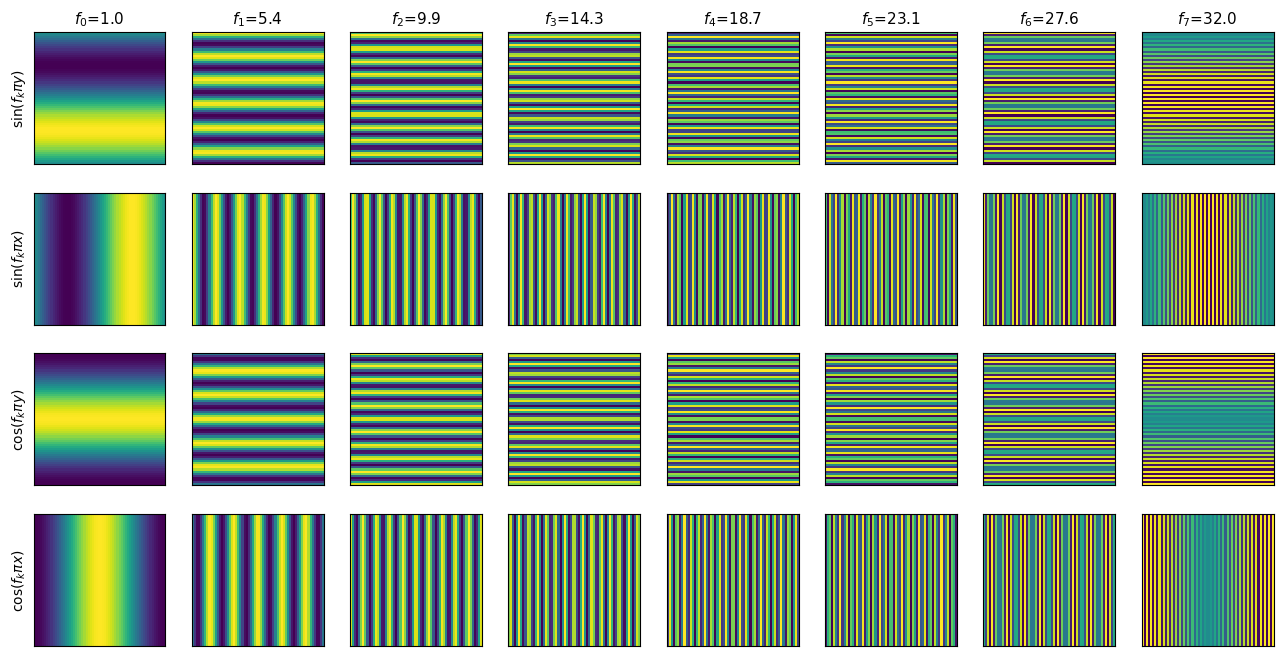

In [8]:
import matplotlib.pyplot as plt

num_bands_to_show = num_bands
fig, axes = plt.subplots(nrows=4, ncols=num_bands_to_show, figsize=(16, 8))

for i in range(num_bands_to_show):
    
    ax0 = axes[0, i]
    ax1 = axes[1, i]
    ax2 = axes[2, i]
    ax3 = axes[3, i]

    # Sine for x and y
    cax0 = ax0.matshow(fourier_features[..., 0, i])
    cax1 = ax1.matshow(fourier_features[..., 1, i])

    # Cosine for x and y
    cax2 = ax2.matshow(fourier_features[..., 0, num_bands + i])
    cax3 = ax3.matshow(fourier_features[..., 1, num_bands + i])

    if i == 0:
        ax0.set_ylabel(r'$\sin (f_k \pi y)$')
        ax1.set_ylabel(r'$\sin (f_k \pi x)$')
        ax2.set_ylabel(r'$\cos (f_k \pi y)$')
        ax3.set_ylabel(r'$\cos (f_k \pi x)$')
        
    ax0.set_title(f'$f_{i}$={frequencies[..., i].item():.1f}', fontsize=11)
    
    for ax in [ax0, ax1, ax2, ax3]:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])

* Each row is sin/cos for y, x (e.g., note how color does not change going left to right when we are plotting y)
* Each column is a different frequency (left to right is low to high)
* Each cell is a heatmap showing the sin/cos wave for the given frequency

In [1]:
from model import Perceiver

In [3]:
import torch

torch.manual_seed(42)
model = Perceiver(
    input_channels=3,
    input_axis=2,
    num_freq_bands=6,
    max_freq=10.0,
    depth=2,
    num_latents=256,
    latent_dim=512,
    cross_heads=2,
    latent_heads=8,
    cross_dim_head=64,
    latent_dim_head=64,
    num_classes=1000,
    self_per_cross_attn=2,
)